This Exploratory Data Analysis (EDA) was conducted to understand the condition and characteristics of the dataset prior to deeper analysis. The examination covers three main aspects: missing values, data distribution, and outliers, within a focus on prev_purchase_date and interpurchase_day as the key variables in understanding customer behavior.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [ ]:
df = pd.read_excel(r'/content/EDA.xlsx')
df.head()

,customer_unique_id,order_id,first_purchase_date,order_purchase_timestamp,prev_purchase_date,order_approved_at,revenue,interpurchase_day,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,2018-05-10 10:56:27,NaT,2018-05-10 11:11:18,141.90,NaN,New Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,2018-05-07 11:11:27,NaT,2018-05-07 18:25:44,27.19,NaN,New Customer
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,2017-03-10 21:05:03,NaT,2017-03-10 21:05:03,86.22,NaN,New Customer
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,2017-10-12 20:29:41,NaT,2017-10-12 20:49:17,43.62,NaN,New Customer
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,2017-11-14 19:45:42,NaT,2017-11-14 20:06:52,196.89,NaN,New Customer


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96479 entries, 0 to 96478
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        96479 non-null  object        
 1   order_id                  96479 non-null  object        
 2   first_purchase_date       96479 non-null  datetime64[ns]
 3   order_purchase_timestamp  96479 non-null  datetime64[ns]
 4   prev_purchase_date        3120 non-null   datetime64[ns]
 5   order_approved_at         96465 non-null  datetime64[ns]
 6   revenue                   96479 non-null  float64       
 7   interpurchase_day         3120 non-null   float64       
 8   customer_type             96479 non-null  object        
dtypes: datetime64[ns](4), float64(2), object(3)
memory usage: 6.6+ MB


Missing values are present in the folling two columns:

* prev_purchase_date: this column no values for the New Cusotmer segment, as these customers are making their first transaction and therefore have no prior purchase data on record.
* interpurchase_day: this column similarly empty for the same segment, since the interpurchase interval cannot be calculated without a previous transaction history.

Both missing values are not data errors, but a logical consequence of the segmentation definition applied in this analysis.

# Interpurchase Day Statistical Summary

In [ ]:
df['interpurchase_day'].describe()

,interpurchase_day
count,3120.000000
mean,79.147436
std,107.295465
min,0.000000
25%,0.000000
50%,29.000000
75%,122.000000
max,609.000000


The interpurchase_day column captures the number of days between transaction for each customer. Overall, the data suggests that customers tend not to make purchases on a frequent or regular basis.

* Mean (79 days): on average, customers return to make a purchase around 79 days after their previous transaction, reflecting a relatively infrequent buying pattern.
* Median (29 days): half of all customers return within 29 days, though this figure is considerably lower than the mean, suggesting that a subset of customers with very long interpurchase intervals is pulling the average upward.
* 75th Percentile (122 days): three quarters of customers have an interpurchase interval of up to 122 days, meaning the majority of customers take more than three months before returning.
* Max (609 days): the longest recorded interval is 609 days, which likely represents an outlier and warrants further investigation.

# Checking the Outliers for Interpurchase Day

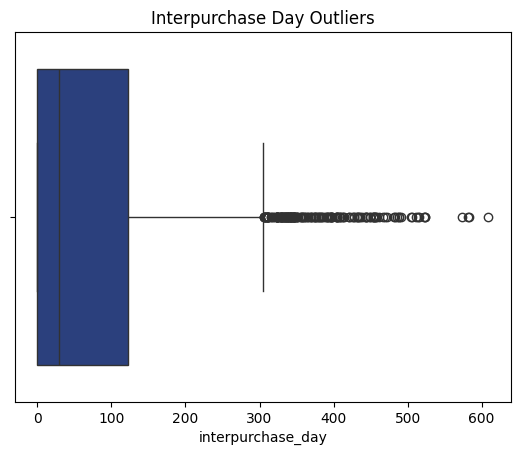

In [ ]:
sns.boxplot(
    x = df['interpurchase_day'],
    color = '#1E3A8A'
)

plt.title('Interpurchase Day Outliers')
plt.show()

The boxplot above confirms what was observed in the earliest statistical summary: the interpurchase_day column contains a considerable number of outliers, with extreme values reaching well beyond 500 days between transactions.

That said, these outliers will not be removed or adjusted. Given that the primary objective of this analysis is to understand real customer growth and behavior within the marketplace, retaining these values is a deliberate choice to ensure the findings accuracy reflect actual conditions on the ground.

Overall, the dataset is in good condition and ready for further analysis. The key findings from this EDA stage are as follows:
* Missing values in the prev_purchase_date and interpurchase_day columns are not data errors, but rather reflect the characteristics of the new customer segment, which has no prior transaction history.
* The distribution of interpurchase_day suggest that customers tend to exhibit irregular purchasing patterns, with a median of 29 days but a considerably higher mean of 79 days, indicating that a subset of customers has significantly longer intervals between transactions.
* Outliers in the interpurchase_day columns were identified but deliberately retained, as these extreme values still represent real cusotmer behavior that is relevant to the objectives of this analysis.

With a thorough understanding of the data's condition and characteristics, the analysis can proceed to the next stage.